In [3]:
import pandas as pd

df = pd.read_csv("/content/student-mat.csv", sep=";")

In [4]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df.shape

(395, 33)

In [6]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


PRIMERA MIRADA

El dataset tiene 395 estudiantes y 33 variables. Contiene datos tanto numéricos como categóricos, relacionados con aspectos personales, familiares, escolares y las calificaciones de los estudiantes.

In [7]:
df[df.duplicated(keep=False)]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3


DUPLICADOS

No se encontraron filas duplicadas en el dataset, por lo que no fue necesario eliminar ningún registro

In [8]:
for columna in df.select_dtypes(include="object").columns:
    print("\n---", columna, "---")
    print(df[columna].value_counts())


--- school ---
school
GP    349
MS     46
Name: count, dtype: int64

--- sex ---
sex
F    208
M    187
Name: count, dtype: int64

--- address ---
address
U    307
R     88
Name: count, dtype: int64

--- famsize ---
famsize
GT3    281
LE3    114
Name: count, dtype: int64

--- Pstatus ---
Pstatus
T    354
A     41
Name: count, dtype: int64

--- Mjob ---
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

--- Fjob ---
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

--- reason ---
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

--- guardian ---
guardian
mother    273
father     90
other      32
Name: count, dtype: int64

--- schoolsup ---
schoolsup
no     344
yes     51
Name: count, dtype: int64

--- famsup ---
famsup
yes    242
no     153
Name: count, dtype: int64

--- paid ---
paid
no     214
yes    181
Name

CATEGORÍAS INCONSISTENTES

Al revisar las variables de texto no encontré categorías repetidas con diferentes formatos. Las categorías se encuentran escritas de manera consistente, por lo que no fue necesario hacer cambios.

In [9]:
df.isna().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


VALORES NULOS

Al revisar los valores nulos, ninguna de las 33 columnas presenta datos faltantes. Por lo tanto, no fue necesario eliminar ni imputar ningún valor.

In [10]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


IMPOSIBLES FRENTE A ATIPICOS

Al revisar los valores mínimos y máximos, no encontré valores claramente imposibles. La edad está entre 15 y 22 años y las calificaciones se encuentran dentro de sus rangos esperados. El valor que más llama la atención es absences, que llega hasta 75; aunque es bastante alto, podría ser real, así que lo considero un posible atípico y no un error.

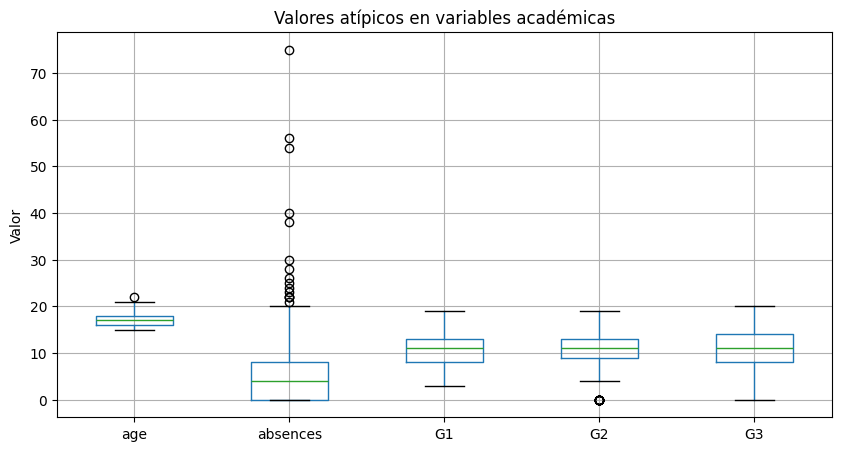

In [11]:
import matplotlib.pyplot as plt

df[["age", "absences", "G1", "G2", "G3"]].boxplot(figsize=(10, 5))
plt.title("Valores atípicos en variables académicas")
plt.ylabel("Valor")
plt.show()

Se observan varios valores atípicos, especialmente en las ausencias. Sin embargo, no necesariamente son errores: un estudiante puede tener muchas ausencias. Las edades y las notas están dentro de rangos posibles, por lo que no eliminaría estos valores solo por ser poco comunes.

In [12]:
print("Filas:", len(df))
print("Columnas:", len(df.columns))
print("Valores nulos:", df.isna().sum().sum())
print("Duplicados:", df.duplicated().sum())

Filas: 395
Columnas: 33
Valores nulos: 0
Duplicados: 0


El dataset tiene 395 filas y 33 columnas. No se encontraron valores nulos ni filas duplicadas. Al revisar los valores numéricos, se observaron algunos valores atípicos, especialmente en las ausencias, pero no necesariamente son errores porque pueden representar estudiantes que faltaron muchas veces.

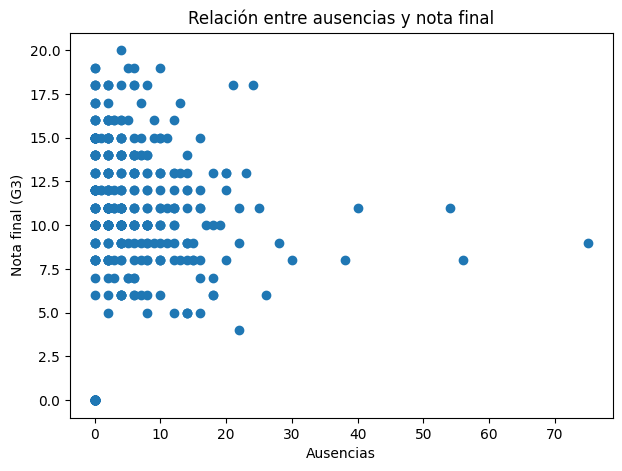

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(df["absences"], df["G3"])
plt.xlabel("Ausencias")
plt.ylabel("Nota final (G3)")
plt.title("Relación entre ausencias y nota final")
plt.show()

Las ausencias y la nota final no muestran una relación clara. La mayoría de estudiantes tiene pocas ausencias, pero también hay algunos con muchas ausencias que mantienen notas medias.

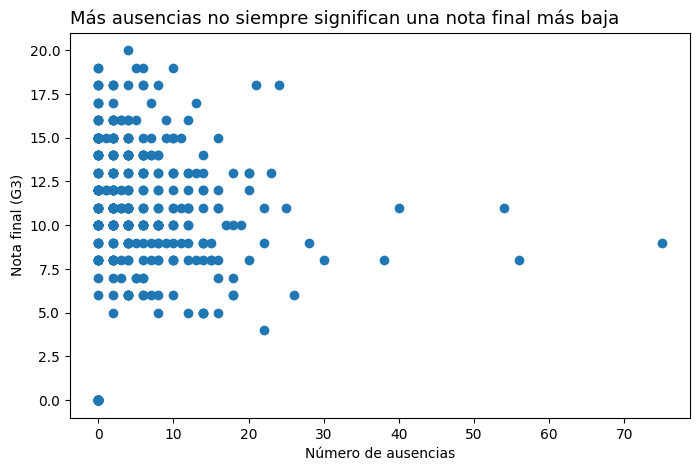

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["absences"], df["G3"])

plt.title("Más ausencias no siempre significan una nota final más baja",
          loc="left", fontsize=13)

plt.xlabel("Número de ausencias")
plt.ylabel("Nota final (G3)")

plt.show()

Un solo gráfico comunicativo

Más ausencias no siempre significan una nota final más baja.
Más ausencias no siempre significan una nota final más baja, ya que hay estudiantes con muchas ausencias que mantienen notas medias.

Checklist

¿El título dice la conclusión? Sí.

¿Se entiende sin explicación? Sí.

¿Hay algo innecesario? No.

¿El gráfico muestra lo importante? Sí, permite comparar ausencias y nota final.

¿Están las unidades? Sí: número de ausencias y nota G3.

¿La comparación es directa? Sí, los puntos muestran ambas variables.

¿Alguien ajeno al proyecto lo entendería? Sí.